# EDA and Pre-Trend Checks
**Step 2.1 — Exploratory Analysis and Parallel Trends Validation**

This notebook performs exploratory data analysis on the cleaned HCV panel dataset and conducts pre-trend checks required before running the difference-in-differences regression. We examine two key outcome variables:
- `number_reported`: number of HCV households per tract (proxy for where voucher holders live)
- `tpoverty`: tract-level poverty rate (%)

The parallel trends assumption — that treatment (Dallas) and control (Houston) tracts would have followed similar trends absent the 2018 SAFMR mandate — is assessed visually and statistically for the pre-treatment period (2014–2017).

## 1. Imports and Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
TREATMENT_COLOR = "#2196F3"  # blue  — Dallas (treated)
CONTROL_COLOR = "#FF7043"  # orange — Houston (control)
POLICY_YEAR = 2018

print("Setup complete.")

Setup complete.


## 2. Load Data

In [15]:
column_dtypes = {
    "code": str,
    "treatment": int,
    "year": int,
    "post": int,
    "poverty_indicator": int,
}

df = pd.read_csv("data/clean_hcv_data.csv", dtype=column_dtypes)

# Readable group label for plots
df["group"] = df["treatment"].map({1: "Dallas (Treatment)", 0: "Houston (Control)"})

print(f"Rows: {len(df):,}  |  Years: {sorted(df['year'].unique())}")
print(
    f"Tracts — Dallas: {df[df.treatment==1]['code'].nunique()}  |  Houston: {df[df.treatment==0]['code'].nunique()}"
)
df.head()

Rows: 5,703  |  Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Tracts — Dallas: 340  |  Houston: 427


,program_label,program,entities,code,number_reported,rent_per_month,hh_income,tpoverty,treatment,year,post,poverty_indicator,group
0,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000401,48113000401,39,297,11131,38,1,2014,0,1,Dallas (Treatment)
1,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000405,48113000405,17,268,10446,40,1,2014,0,1,Dallas (Treatment)
2,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000500,48113000500,25,202,8242,17,1,2014,0,0,Dallas (Treatment)
3,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000601,48113000601,17,336,12377,35,1,2014,0,1,Dallas (Treatment)
4,Housing Choice Vouchers,3,TX Texas 113 Dallas County 48113000800,48113000800,123,326,11988,27,1,2014,0,0,Dallas (Treatment)


## 3. Dataset Overview

In [16]:
# Summary statistics by group
summary = (
    df.groupby("group")[["number_reported", "tpoverty", "hh_income", "rent_per_month"]]
    .describe()
    .round(2)
)
summary

number_reported                                        \
                             count   mean    std   min   25%   50%   75%   
group                                                                      
Dallas (Treatment)          2576.0  77.05  84.39  11.0  23.0  49.0  95.0   
Houston (Control)           3127.0  62.78  63.39  11.0  20.0  40.0  81.0   

                          tpoverty         ... hh_income           \
                      max    count   mean  ...       75%      max   
group                                      ...                      
Dallas (Treatment)  681.0   2576.0  21.25  ...   17756.0  30552.0   
Houston (Control)   535.0   3127.0  22.69  ...   16444.5  39600.0   

                   rent_per_month                                              \
                            count    mean     std    min    25%    50%    75%   
group                                                                           
Dallas (Treatment)         2576.0  422.73  113.66  171.0  337.0  407.5  494.0   
Houston (Control)          3127.0  392.75  113.89   82.0  317.0  373.0  455.0   

                            
                       max  
group                       
Dallas (Treatment)  1084.0  
Houston (Control)    906.0  

[2 rows x 32 columns]

In [17]:
# Observation count by group and year
obs_table = df.groupby(["year", "group"]).size().unstack()
print("Tract-year observations by group:")
obs_table

Tract-year observations by group:


group,Dallas (Treatment),Houston (Control)
year,,
2014,319,344
2015,306,343
2016,297,340
2017,286,345
2018,277,347
2019,279,351
2020,278,357
2021,273,342
2022,261,358


## 4. Distribution of Key Variables

Before examining trends, we look at the distributions of `number_reported` and `tpoverty` across the full panel, separately for treatment and control groups.

/var/folders/d9/jrdhm0fs42jgp293l0fm5cnm0000gn/T/ipykernel_82005/1304638176.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d9/jrdhm0fs42jgp293l0fm5cnm0000gn/T/ipykernel_82005/1304638176.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


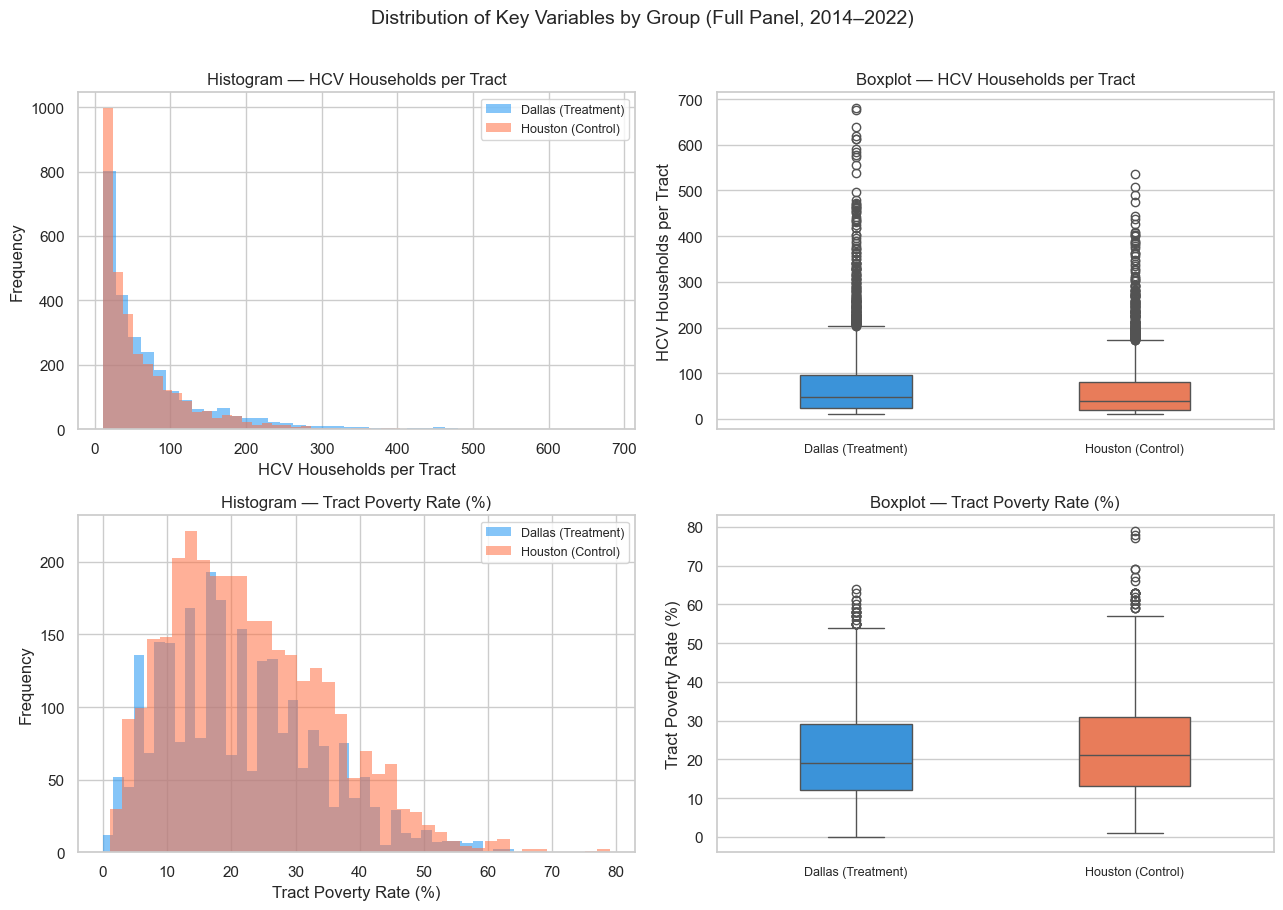

Figure saved.


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    "Distribution of Key Variables by Group (Full Panel, 2014–2022)",
    fontsize=14,
    y=1.01,
)

plot_vars = [
    ("number_reported", "HCV Households per Tract"),
    ("tpoverty", "Tract Poverty Rate (%)"),
]

for col_idx, (var, label) in enumerate(plot_vars):
    # Histogram
    ax = axes[col_idx][0]
    for grp, color in [
        ("Dallas (Treatment)", TREATMENT_COLOR),
        ("Houston (Control)", CONTROL_COLOR),
    ]:
        vals = df[df["group"] == grp][var].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=grp, edgecolor="none")
    ax.set_title(f"Histogram — {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

    # Boxplot
    ax2 = axes[col_idx][1]
    subset = df[["group", var]].dropna()
    order = ["Dallas (Treatment)", "Houston (Control)"]
    palette = {
        "Dallas (Treatment)": TREATMENT_COLOR,
        "Houston (Control)": CONTROL_COLOR,
    }
    sns.boxplot(
        data=subset, x="group", y=var, order=order, palette=palette, ax=ax2, width=0.4
    )
    ax2.set_title(f"Boxplot — {label}")
    ax2.set_xlabel("")
    ax2.set_ylabel(label)
    ax2.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 5. Pre-Trend Checks

The difference-in-differences estimator is only valid if treatment and control groups were on parallel trajectories before the policy took effect. We check this for both outcome variables over the pre-treatment period (2014–2017).

### 5.1 HCV Households per Tract (`number_reported`)

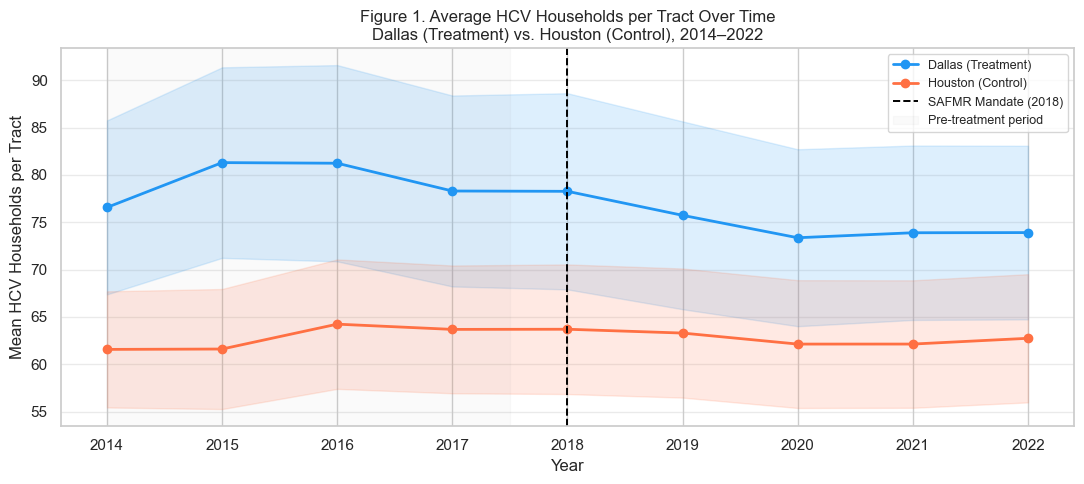

Figure saved.


In [19]:
# Aggregate to group-year means
trends_nr = (
    df.groupby(["year", "group"])["number_reported"].agg(["mean", "sem"]).reset_index()
)
trends_nr.columns = ["year", "group", "mean", "sem"]

fig, ax = plt.subplots(figsize=(11, 5))

for grp, color in [
    ("Dallas (Treatment)", TREATMENT_COLOR),
    ("Houston (Control)", CONTROL_COLOR),
]:
    sub = trends_nr[trends_nr["group"] == grp]
    ax.plot(sub["year"], sub["mean"], marker="o", color=color, label=grp, linewidth=2)
    ax.fill_between(
        sub["year"],
        sub["mean"] - 1.96 * sub["sem"],
        sub["mean"] + 1.96 * sub["sem"],
        alpha=0.15,
        color=color,
    )

ax.axvline(
    POLICY_YEAR,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="SAFMR Mandate (2018)",
)
ax.axvspan(
    df["year"].min(),
    POLICY_YEAR - 0.5,
    alpha=0.04,
    color="gray",
    label="Pre-treatment period",
)

ax.set_title(
    "Figure 1. Average HCV Households per Tract Over Time\nDallas (Treatment) vs. Houston (Control), 2014–2022",
    fontsize=12,
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean HCV Households per Tract")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("02_pretrend_number_reported.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

### 5.2 Tract Poverty Rate (`tpoverty`)

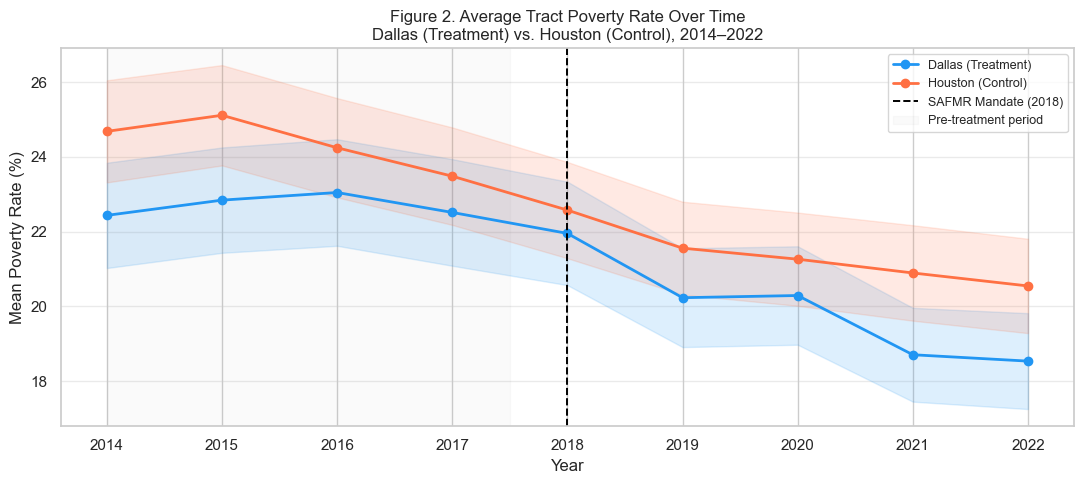

Figure saved.


In [20]:
trends_pov = (
    df.groupby(["year", "group"])["tpoverty"].agg(["mean", "sem"]).reset_index()
)
trends_pov.columns = ["year", "group", "mean", "sem"]

fig, ax = plt.subplots(figsize=(11, 5))

for grp, color in [
    ("Dallas (Treatment)", TREATMENT_COLOR),
    ("Houston (Control)", CONTROL_COLOR),
]:
    sub = trends_pov[trends_pov["group"] == grp]
    ax.plot(sub["year"], sub["mean"], marker="o", color=color, label=grp, linewidth=2)
    ax.fill_between(
        sub["year"],
        sub["mean"] - 1.96 * sub["sem"],
        sub["mean"] + 1.96 * sub["sem"],
        alpha=0.15,
        color=color,
    )

ax.axvline(
    POLICY_YEAR,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label="SAFMR Mandate (2018)",
)
ax.axvspan(
    df["year"].min(),
    POLICY_YEAR - 0.5,
    alpha=0.04,
    color="gray",
    label="Pre-treatment period",
)

ax.set_title(
    "Figure 2. Average Tract Poverty Rate Over Time\nDallas (Treatment) vs. Houston (Control), 2014–2022",
    fontsize=12,
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean Poverty Rate (%)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("03_pretrend_tpoverty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

### 5.3 Pre-Trend Statistical Test

We formally test the parallel trends assumption by regressing each outcome on a `treatment × year` interaction using **only the pre-treatment years (2014–2017)**. If the groups were truly on parallel trends, the interaction coefficient should be statistically indistinguishable from zero.

In [21]:
pre = df[df["year"] < POLICY_YEAR].copy()

for outcome, label in [
    ("number_reported", "HCV Households per Tract"),
    ("tpoverty", "Poverty Rate (%)"),
]:
    model = smf.ols(f"{outcome} ~ treatment * year", data=pre).fit(
        cov_type="cluster", cov_kwds={"groups": pre["code"]}
    )
    coef = model.params["treatment:year"]
    pval = model.pvalues["treatment:year"]
    ci_lo, ci_hi = model.conf_int().loc["treatment:year"]

    print(f"Outcome: {label}")
    print(f"  treatment × year coefficient: {coef:.4f}")
    print(f"  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(
        f"  p-value: {pval:.4f}  {'✓ Not significant — consistent with parallel trends' if pval > 0.05 else '✗ Significant — parallel trends may be violated'}"
    )
    print()

Outcome: HCV Households per Tract
  treatment × year coefficient: -0.3248
  95% CI: [-2.0898, 1.4401]
  p-value: 0.7183  ✓ Not significant — consistent with parallel trends

Outcome: Poverty Rate (%)
  treatment × year coefficient: 0.4977
  95% CI: [0.0114, 0.9840]
  p-value: 0.0449  ✗ Significant — parallel trends may be violated



## 6. Pre-Treatment Balance Check

Beyond trend parallelism, we check whether the groups were at comparable baseline levels in key covariates during the pre-treatment period.

In [22]:
pre_means = (
    pre.groupby("group")[["number_reported", "tpoverty", "hh_income", "rent_per_month"]]
    .mean()
    .round(2)
    .T
)
pre_means.columns.name = None
pre_means.index.name = "Variable"
pre_means["Difference (Dallas − Houston)"] = (
    pre_means["Dallas (Treatment)"] - pre_means["Houston (Control)"]
).round(2)

print("Pre-treatment means (2014–2017):")
pre_means

Pre-treatment means (2014–2017):


,Dallas (Treatment),Houston (Control),Difference (Dallas − Houston)
Variable,,,
number_reported,79.32,62.76,16.56
tpoverty,22.71,24.38,-1.67
hh_income,14341.90,13913.16,428.74
rent_per_month,409.07,377.44,31.63


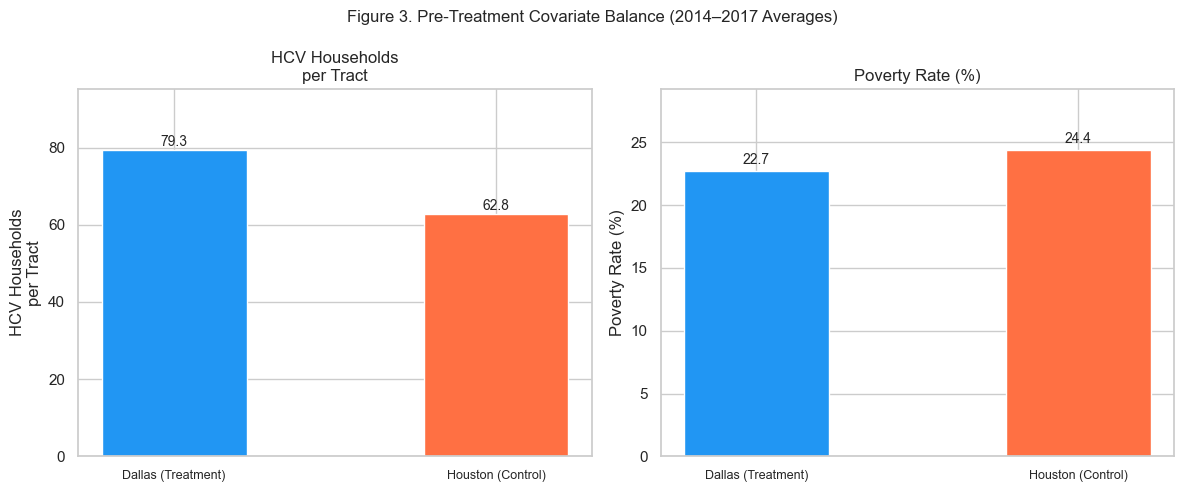

Figure saved.


In [23]:
# Visualize pre-treatment balance as a bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Figure 3. Pre-Treatment Covariate Balance (2014–2017 Averages)", fontsize=12
)

balance_vars = [
    ("number_reported", "HCV Households\nper Tract"),
    ("tpoverty", "Poverty Rate (%)"),
]

for ax, (var, label) in zip(axes, balance_vars):
    vals = pre.groupby("group")[var].mean()
    colors = [TREATMENT_COLOR, CONTROL_COLOR]
    bars = ax.bar(vals.index, vals.values, color=colors, width=0.45, edgecolor="white")
    for bar, val in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=9)
    ax.set_ylim(0, vals.max() * 1.2)

plt.tight_layout()
plt.savefig("04_balance_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 7. Summary of Findings

Run this cell to print a brief interpretive summary — useful for writing the memo.

In [24]:
pre_dallas = pre[pre["treatment"] == 1]
pre_houston = pre[pre["treatment"] == 0]

print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df):,} tract-year obs | {df['year'].min()}–{df['year'].max()}")
print(
    f"Dallas tracts: {df[df.treatment==1]['code'].nunique()} | Houston tracts: {df[df.treatment==0]['code'].nunique()}"
)

print("\nPre-treatment means (2014–2017):")
for var, label in [
    ("number_reported", "HCV households/tract"),
    ("tpoverty", "Poverty rate (%)"),
]:
    d_mean = pre_dallas[var].mean()
    h_mean = pre_houston[var].mean()
    print(
        f"  {label}: Dallas={d_mean:.1f}, Houston={h_mean:.1f}, diff={d_mean-h_mean:.1f}"
    )

print("\nParallel trends test (treatment × year, pre-period only):")
for outcome, label in [
    ("number_reported", "HCV households"),
    ("tpoverty", "Poverty rate"),
]:
    model = smf.ols(f"{outcome} ~ treatment * year", data=pre).fit(
        cov_type="cluster", cov_kwds={"groups": pre["code"]}
    )
    pval = model.pvalues["treatment:year"]
    result = (
        "NOT significant (p>{:.2f}) — parallel trends supported".format(0.05)
        if pval > 0.05
        else "SIGNIFICANT — trends differ pre-treatment"
    )
    print(f"  {label}: p={pval:.3f} → {result}")

print("\nNote: The 2018 SAFMR mandate marks the start of treatment.")
print("Post-treatment effects are estimated in notebook 02_DiD.")

EDA SUMMARY

Dataset: 5,703 tract-year obs | 2014–2022
Dallas tracts: 340 | Houston tracts: 427

Pre-treatment means (2014–2017):
  HCV households/tract: Dallas=79.3, Houston=62.8, diff=16.6
  Poverty rate (%): Dallas=22.7, Houston=24.4, diff=-1.7

Parallel trends test (treatment × year, pre-period only):
  HCV households: p=0.718 → NOT significant (p>0.05) — parallel trends supported
  Poverty rate: p=0.045 → SIGNIFICANT — trends differ pre-treatment

Note: The 2018 SAFMR mandate marks the start of treatment.
Post-treatment effects are estimated in notebook 02_DiD.
